# Exercise 4

This exercise focuses on data visualization and interpretation using a real-world COVID-19 dataset. The dataset contains daily records of confirmed cases, deaths, recoveries, and active cases across countries and regions, along with temporal and geographic information.
The goal of this exercise is not only to create charts, but to choose appropriate visualizations, apply correct data aggregation, and draw meaningful insights from the data. You will work with time-based, categorical, numerical, and geographic variables, and you are expected to think critically about how design choices affect interpretation.

Your visualizations should follow good practices:
- Use clear titles, axis labels, and legends
- Choose chart types appropriate to the data and question
- Avoid misleading scales or cluttered designs
- Clearly explain patterns, trends, or anomalies you observe

Unless stated otherwise, you may filter, aggregate, or group the data as needed.

<img src="https://d3i6fh83elv35t.cloudfront.net/static/2020/03/Screen-Shot-2020-03-05-at-6.29.29-PM-1024x574.png"/>

In [29]:
import kagglehub
import os
import pandas as pd

# Download latest version
path = kagglehub.dataset_download("imdevskp/corona-virus-report")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'corona-virus-report' dataset.
Path to dataset files: /kaggle/input/corona-virus-report


In [30]:
if os.path.isdir(path):
  print(True)

contents = os.listdir(path)
contents

mydataset = path + "/" + contents[0]
mydataset


df = pd.read_csv(mydataset)

True


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Province/State  14664 non-null  object 
 1   Country/Region  49068 non-null  object 
 2   Lat             49068 non-null  float64
 3   Long            49068 non-null  float64
 4   Date            49068 non-null  object 
 5   Confirmed       49068 non-null  int64  
 6   Deaths          49068 non-null  int64  
 7   Recovered       49068 non-null  int64  
 8   Active          49068 non-null  int64  
 9   WHO Region      49068 non-null  object 
dtypes: float64(2), int64(4), object(4)
memory usage: 3.7+ MB


In [32]:
df.head(10)

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa
5,NaN,Antigua and Barbuda,17.06080,-61.796400,2020-01-22,0,0,0,0,Americas
6,NaN,Argentina,-38.41610,-63.616700,2020-01-22,0,0,0,0,Americas
7,NaN,Armenia,40.06910,45.038200,2020-01-22,0,0,0,0,Europe
8,Australian Capital Territory,Australia,-35.47350,149.012400,2020-01-22,0,0,0,0,Western Pacific
9,New South Wales,Australia,-33.86880,151.209300,2020-01-22,0,0,0,0,Western Pacific


In [33]:
df.query("`Country/Region` == 'Philippines'")

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
180,NaN,Philippines,12.879721,121.774017,2020-01-22,0,0,0,0,Western Pacific
441,NaN,Philippines,12.879721,121.774017,2020-01-23,0,0,0,0,Western Pacific
702,NaN,Philippines,12.879721,121.774017,2020-01-24,0,0,0,0,Western Pacific
963,NaN,Philippines,12.879721,121.774017,2020-01-25,0,0,0,0,Western Pacific
1224,NaN,Philippines,12.879721,121.774017,2020-01-26,0,0,0,0,Western Pacific
...,...,...,...,...,...,...,...,...,...,...
47943,NaN,Philippines,12.879721,121.774017,2020-07-23,74390,1871,24383,48136,Western Pacific
48204,NaN,Philippines,12.879721,121.774017,2020-07-24,76444,1879,24502,50063,Western Pacific
48465,NaN,Philippines,12.879721,121.774017,2020-07-25,78412,1897,25752,50763,Western Pacific
48726,NaN,Philippines,12.879721,121.774017,2020-07-26,80448,1932,26110,52406,Western Pacific


In [34]:
df.describe()

,Lat,Long,Confirmed,Deaths,Recovered,Active
count,49068.000000,49068.000000,4.906800e+04,49068.000000,4.906800e+04,4.906800e+04
mean,21.433730,23.528236,1.688490e+04,884.179160,7.915713e+03,8.085012e+03
std,24.950320,70.442740,1.273002e+05,6313.584411,5.480092e+04,7.625890e+04
min,-51.796300,-135.000000,0.000000e+00,0.000000,0.000000e+00,-1.400000e+01
25%,7.873054,-15.310100,4.000000e+00,0.000000,0.000000e+00,0.000000e+00
50%,23.634500,21.745300,1.680000e+02,2.000000,2.900000e+01,2.600000e+01
75%,41.204380,80.771797,1.518250e+03,30.000000,6.660000e+02,6.060000e+02
max,71.706900,178.065000,4.290259e+06,148011.000000,1.846641e+06,2.816444e+06


## A. Time-Based Visualizations

1. Global Trend `(5 pts)`

Aggregate the data by Date and create a line chart showing the global number of confirmed COVID-19 cases over time.

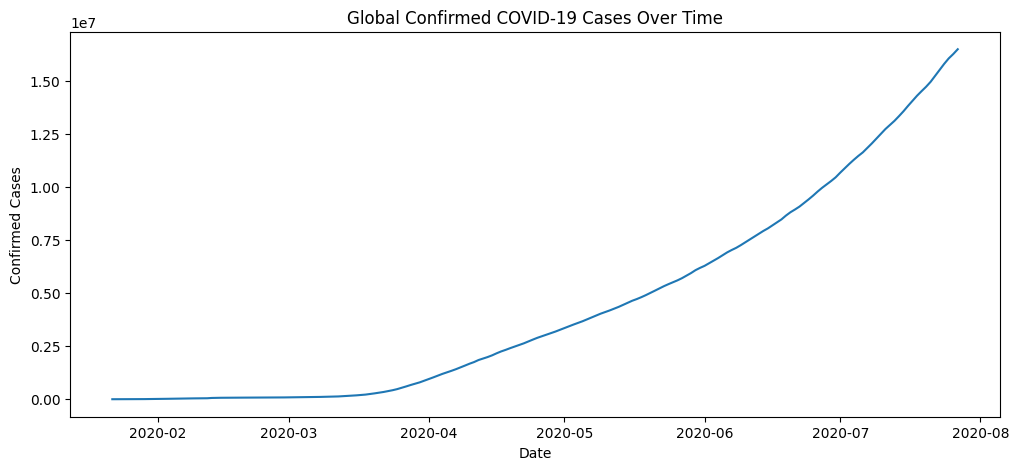

In [67]:
# put your answer here

global_trend = (

df.groupby("Date")["Confirmed"]

.sum()

.reset_index()

)

global_trend["Date"] = pd.to_datetime(global_trend["Date"])


fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(global_trend["Date"], global_trend["Confirmed"])
ax.set_title("Global Confirmed COVID-19 Cases Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("Confirmed Cases")
plt.show()

2. Country-Level Trends `(5 pts)`

Select three countries and visualize their confirmed case counts over time on the same plot.

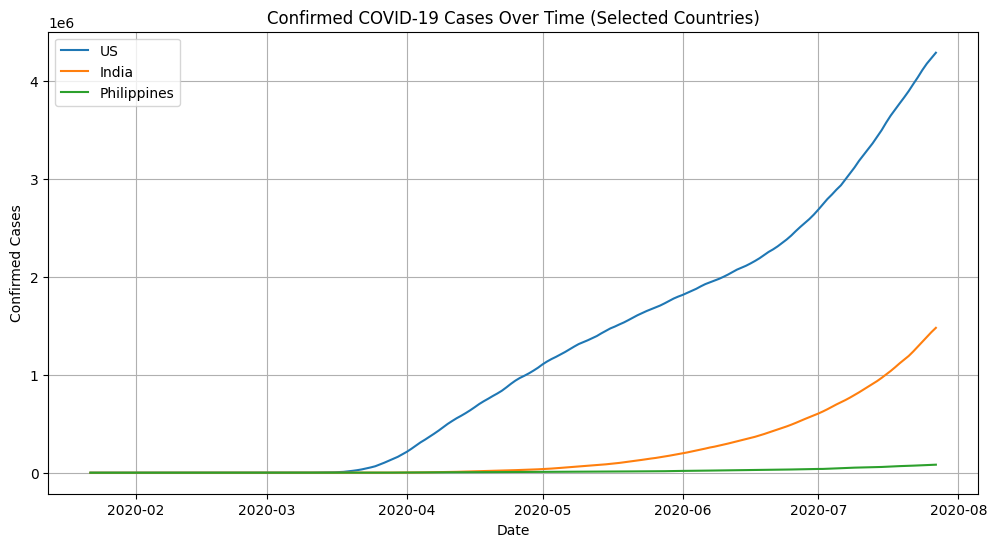

In [62]:
# put your answer here
import matplotlib.pyplot as plt

countries = ['US', 'India', 'Philippines']

country_df = df[df['Country/Region'].isin(countries)]

plt.figure(figsize=(12,6))

for country in countries:
    temp = country_df[country_df['Country/Region'] == country]
    plt.plot(temp['Date'], temp['Confirmed'], label=country)

plt.title('Confirmed COVID-19 Cases Over Time (Selected Countries)')
plt.xlabel('Date')
plt.ylabel('Confirmed Cases')
plt.legend()
plt.grid(True)
plt.show()


3. Active vs Recovered `(5 pts)`

For a selected country, create a line chart showing Active and Recovered cases over time.

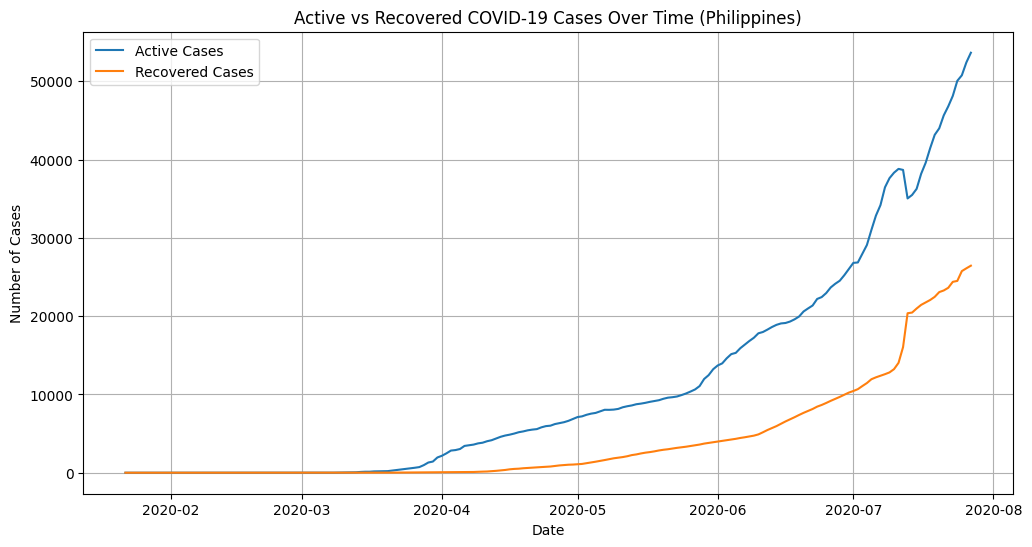

In [54]:
# put your answer here

country = 'Philippines'
country_df = df[df['Country/Region'] == country]

plt.figure(figsize=(12,6))

plt.plot(country_df['Date'], country_df['Active'], label='Active Cases')
plt.plot(country_df['Date'], country_df['Recovered'], label='Recovered Cases')

plt.title(f'Active vs Recovered COVID-19 Cases Over Time ({country})')
plt.xlabel('Date')
plt.ylabel('Number of Cases')
plt.legend()
plt.grid(True)
plt.show()

## B: Comparative Visualizations

4. Country Comparison `(5 pts)`

Using data from a single date, create a bar chart showing the top 10 countries by confirmed cases.

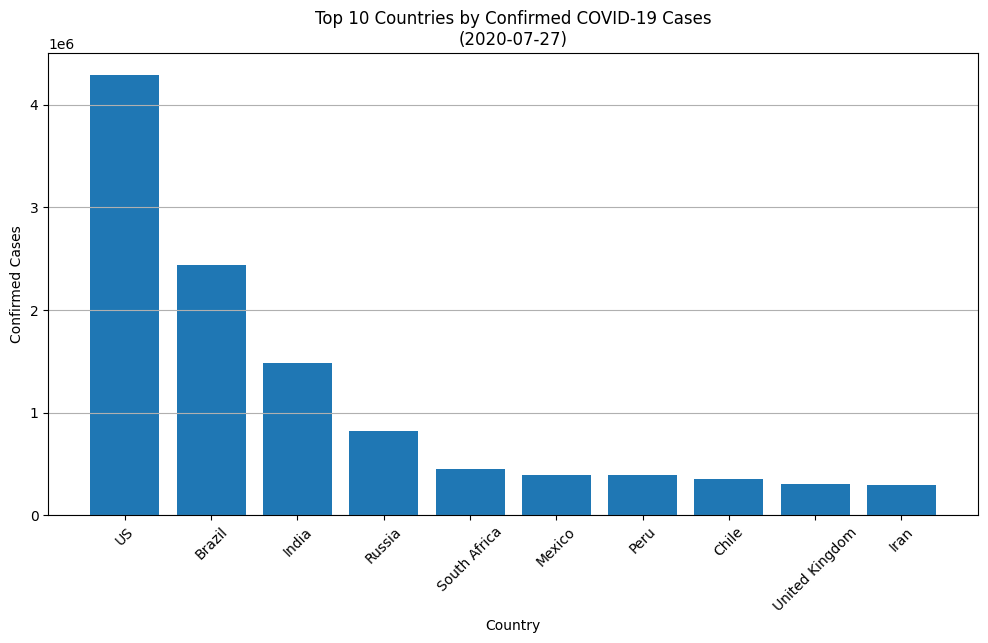

In [58]:
# put your answer here

df['Date'] = pd.to_datetime(df['Date'])

# Select a single date (latest date in the dataset)
selected_date = df['Date'].max()

# Filter data for the selected date
date_df = df[df['Date'] == selected_date]

# Group by country and get confirmed cases
top10 = (
    date_df
    .groupby('Country/Region')['Confirmed']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

# Plot bar chart
plt.figure(figsize=(12,6))
plt.bar(top10.index, top10.values)
plt.title(f'Top 10 Countries by Confirmed COVID-19 Cases\n({selected_date.date()})')
plt.xlabel('Country')
plt.ylabel('Confirmed Cases')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

5. WHO Region Comparison `(5 pts)`

Aggregate confirmed cases by WHO Region and visualize the result using a bar chart.

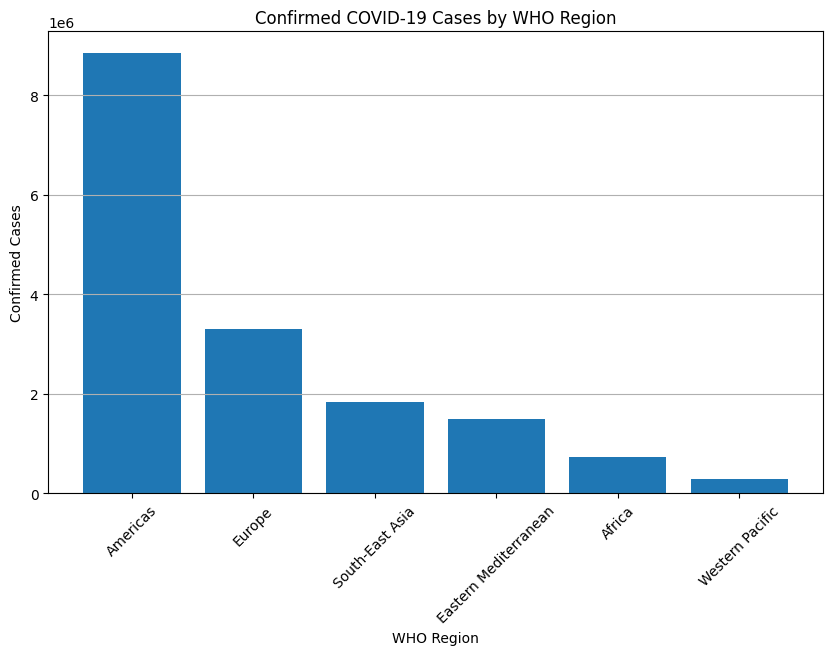

In [59]:
# put your answer here
df['Date'] = pd.to_datetime(df['Date'])

latest_date = df['Date'].max()
latest_df = df[df['Date'] == latest_date]

region_cases = (
    latest_df
    .groupby('WHO Region')['Confirmed']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))
plt.bar(region_cases.index, region_cases.values)
plt.title('Confirmed COVID-19 Cases by WHO Region')
plt.xlabel('WHO Region')
plt.ylabel('Confirmed Cases')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.show()

## C. Geographic Visualization

6. Geographic Spread `(10 pts)`

Using Latitude and Longitude, create a map-based visualization showing confirmed cases for a selected date.

In [60]:
# put your answer here

import pandas as pd
import plotly.express as px

df['Date'] = pd.to_datetime(df['Date'])

selected_date = df['Date'].max()
date_df = df[df['Date'] == selected_date]

fig = px.scatter_geo(
    date_df,
    lat='Lat',
    lon='Long',
    size='Confirmed',
    color='Confirmed',
    hover_name='Country/Region',
    size_max=40,
    projection='natural earth',
    title=f'Geographic Spread of Confirmed COVID-19 Cases ({selected_date.date()})'
)

fig.show()

7. Regional Clustering `(15 pts)`

Create a visualization that shows how confirmed cases are distributed geographically within a single WHO Region.

In [65]:
# put your answer here
import pandas as pd
import plotly.express as px

df['Date'] = pd.to_datetime(df['Date'])

asia_regions = ['Eastern Mediterranean', 'South-East Asia', 'Western Pacific']

selected_date = df['Date'].max()

asia_df = df[(df['WHO Region'].isin(asia_regions)) & (df['Date'] == selected_date)]

fig = px.scatter_geo(
    asia_df,
    lat='Lat',
    lon='Long',
    size='Confirmed',
    color='Confirmed',
    hover_name='Country/Region',
    projection='natural earth',
    size_max=40,
    title=f'Geographic Distribution of Confirmed COVID-19 Cases in Asia ({selected_date.date()})'
)

fig.show()

In [66]:
import pandas as pd
import plotly.express as px

# Ensure Date is datetime
df['Date'] = pd.to_datetime(df['Date'])

# Choose a WHO Region and a single date
who_region = 'Western Pacific'
selected_date = df['Date'].max()

# Filter data for the selected WHO Region and date
region_df = df[(df['WHO Region'] == who_region) & (df['Date'] == selected_date)]

# Map-based scatter plot
fig = px.scatter_geo(
    region_df,
    lat='Lat',
    lon='Long',
    size='Confirmed',
    color='Confirmed',
    hover_name='Country/Region',
    projection='natural earth',
    size_max=40,
    title=f'Geographic Distribution of Confirmed Cases in {who_region} ({selected_date.date()})'
)

fig.show()